In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import re

In [3]:
# Inception Block with BatchNorm

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3reduce, ch3x3, ch5x5reduce, ch5x5, pool_proj):
        super(InceptionBlock, self).__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1),
            nn.BatchNorm2d(ch1x1),
            nn.ReLU(True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3reduce, kernel_size=1),
            nn.BatchNorm2d(ch3x3reduce),
            nn.ReLU(True),
            nn.Conv2d(ch3x3reduce, ch3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(ch3x3),
            nn.ReLU(True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5reduce, kernel_size=1),
            nn.BatchNorm2d(ch5x5reduce),
            nn.ReLU(True),
            nn.Conv2d(ch5x5reduce, ch5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(ch5x5),
            nn.ReLU(True)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(True)
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], 1)


In [4]:
# Auxiliary Classifier

class AuxiliaryClassifier(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(AuxiliaryClassifier, self).__init__()
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.conv = nn.Conv2d(in_channels, 128, kernel_size=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.avgpool(x)
        x = F.relu(self.conv(x))
        x = torch.flatten(x, 1)
        x = F.dropout(F.relu(self.fc1(x)), 0.5, training=self.training)
        x = self.fc2(x)
        return x

In [5]:
# GoogLeNet

class GoogLeNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super(GoogLeNetCIFAR, self).__init__()
        self.pre_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )

        self.inception3a = InceptionBlock(64, 64, 96, 128, 16, 32, 32)
        self.inception3b = InceptionBlock(256, 128, 128, 192, 32, 96, 64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception4a = InceptionBlock(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = InceptionBlock(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = InceptionBlock(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = InceptionBlock(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = InceptionBlock(528, 256, 160, 320, 32, 128, 128)

        self.inception5a = InceptionBlock(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = InceptionBlock(832, 384, 192, 384, 48, 128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

        # Aux classifiers
        self.aux1 = AuxiliaryClassifier(512, num_classes)
        self.aux2 = AuxiliaryClassifier(528, num_classes)

    def forward(self, x):
        x = self.pre_layers(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool(x)

        x = self.inception4a(x)
        aux1 = self.aux1(x) if self.training else None

        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        aux2 = self.aux2(x) if self.training else None

        x = self.inception4e(x)
        x = self.maxpool(x)

        x = self.inception5a(x)
        x = self.inception5b(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x, aux1, aux2

In [6]:
# Prepare CIFAR-10 Data

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:01<00:00, 90.2MB/s] 


In [7]:
# Training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GoogLeNetCIFAR().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs, aux1, aux2 = model(images)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux1, labels)
        loss3 = criterion(aux2, labels)
        loss = loss1 + 0.3 * (loss2 + loss3)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, Accuracy: {100*correct/total:.2f}%")

Epoch 1/50: 100%|██████████| 391/391 [02:29<00:00,  2.61it/s]


Epoch [1/50], Loss: 2.0793, Accuracy: 52.40%


Epoch 2/50: 100%|██████████| 391/391 [02:33<00:00,  2.54it/s]


Epoch [2/50], Loss: 1.3899, Accuracy: 69.93%


Epoch 3/50: 100%|██████████| 391/391 [02:33<00:00,  2.54it/s]


...

Epoch [48/50], Loss: 0.0762, Accuracy: 99.64%


Epoch 49/50: 100%|██████████| 391/391 [02:29<00:00,  2.61it/s]


Epoch [49/50], Loss: 0.0762, Accuracy: 99.60%


Epoch 50/50: 100%|██████████| 391/391 [02:29<00:00,  2.62it/s]

Epoch [50/50], Loss: 0.0776, Accuracy: 99.57%


In [9]:
# Testing

# Testing
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Unpack if outputs is a tuple
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")

Test Accuracy: 91.21%


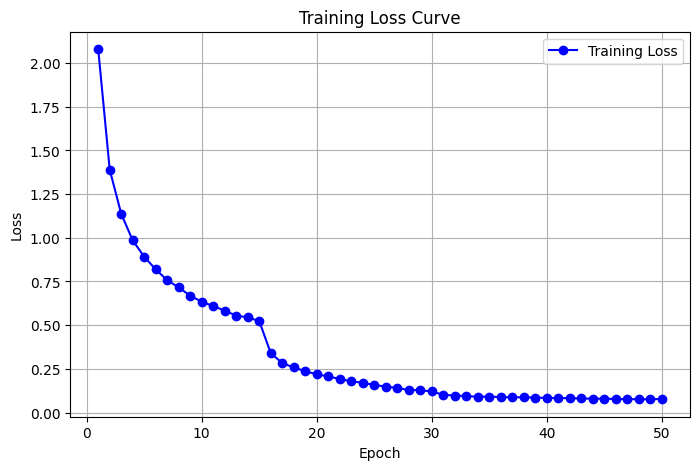

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot Training Loss

logs = """
Epoch [1/50], Loss: 2.0793, Accuracy: 52.40%
Epoch [2/50], Loss: 1.3899, Accuracy: 69.93%
Epoch [3/50], Loss: 1.1373, Accuracy: 76.57%
Epoch [4/50], Loss: 0.9852, Accuracy: 79.92%
Epoch [5/50], Loss: 0.8916, Accuracy: 82.30%
Epoch [6/50], Loss: 0.8191, Accuracy: 83.75%
Epoch [7/50], Loss: 0.7572, Accuracy: 85.17%
Epoch [8/50], Loss: 0.7159, Accuracy: 86.30%
Epoch [9/50], Loss: 0.6683, Accuracy: 87.08%
Epoch [10/50], Loss: 0.6342, Accuracy: 87.86%
Epoch [11/50], Loss: 0.6092, Accuracy: 88.44%
Epoch [12/50], Loss: 0.5829, Accuracy: 89.00%
Epoch [13/50], Loss: 0.5547, Accuracy: 89.71%
Epoch [14/50], Loss: 0.5448, Accuracy: 89.77%
Epoch [15/50], Loss: 0.5234, Accuracy: 90.35%
Epoch [16/50], Loss: 0.3402, Accuracy: 94.21%
Epoch [17/50], Loss: 0.2830, Accuracy: 95.47%
Epoch [18/50], Loss: 0.2578, Accuracy: 95.96%
Epoch [19/50], Loss: 0.2367, Accuracy: 96.40%
Epoch [20/50], Loss: 0.2187, Accuracy: 96.80%
Epoch [21/50], Loss: 0.2068, Accuracy: 97.00%
Epoch [22/50], Loss: 0.1914, Accuracy: 97.41%
Epoch [23/50], Loss: 0.1788, Accuracy: 97.58%
Epoch [24/50], Loss: 0.1701, Accuracy: 97.78%
Epoch [25/50], Loss: 0.1577, Accuracy: 98.07%
Epoch [26/50], Loss: 0.1485, Accuracy: 98.25%
Epoch [27/50], Loss: 0.1407, Accuracy: 98.44%
Epoch [28/50], Loss: 0.1292, Accuracy: 98.70%
Epoch [29/50], Loss: 0.1280, Accuracy: 98.58%
Epoch [30/50], Loss: 0.1204, Accuracy: 98.77%
Epoch [31/50], Loss: 0.1015, Accuracy: 99.14%
Epoch [32/50], Loss: 0.0972, Accuracy: 99.26%
Epoch [33/50], Loss: 0.0946, Accuracy: 99.32%
Epoch [34/50], Loss: 0.0902, Accuracy: 99.38%
Epoch [35/50], Loss: 0.0914, Accuracy: 99.40%
Epoch [36/50], Loss: 0.0884, Accuracy: 99.40%
Epoch [37/50], Loss: 0.0873, Accuracy: 99.46%
Epoch [38/50], Loss: 0.0871, Accuracy: 99.40%
Epoch [39/50], Loss: 0.0860, Accuracy: 99.45%
Epoch [40/50], Loss: 0.0833, Accuracy: 99.54%
Epoch [41/50], Loss: 0.0832, Accuracy: 99.52%
Epoch [42/50], Loss: 0.0820, Accuracy: 99.54%
Epoch [43/50], Loss: 0.0805, Accuracy: 99.54%
Epoch [44/50], Loss: 0.0793, Accuracy: 99.57%
Epoch [45/50], Loss: 0.0792, Accuracy: 99.57%
Epoch [46/50], Loss: 0.0777, Accuracy: 99.58%
Epoch [47/50], Loss: 0.0765, Accuracy: 99.63%
Epoch [48/50], Loss: 0.0762, Accuracy: 99.64%
Epoch [49/50], Loss: 0.0762, Accuracy: 99.60%
Epoch [50/50], Loss: 0.0776, Accuracy: 99.57%
"""

epochs = []
losses = []
accuracies = []

for line in logs.strip().split("\n"):
    match = re.search(r"Epoch \[(\d+)/\d+\], Loss: ([\d.]+), Accuracy: ([\d.]+)%", line)
    if match:
        epochs.append(int(match.group(1)))
        losses.append(float(match.group(2)))
        accuracies.append(float(match.group(3)))

plt.figure(figsize=(8,5))
plt.plot(epochs, losses, label="Training Loss", color="blue", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid()
plt.show()

plt.savefig("training_loss.png", dpi=300, bbox_inches='tight')

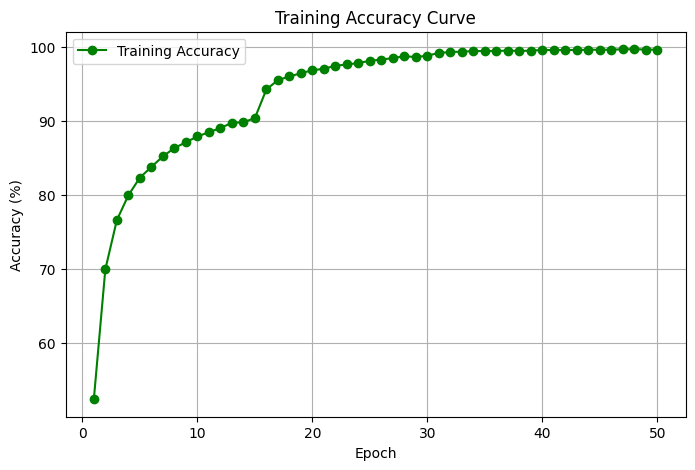

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot Training Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, accuracies, label="Training Accuracy", color="green", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

plt.savefig("training_accuracy.png", dpi=300, bbox_inches='tight')

In [ ]:
torch.save(model.state_dict(), "Inception-v1.pth")
print("✅ Full model saved as Inception-v1.pth")

✅ Full model saved as Inception-v1.pth
